In [1]:
import warnings
from typing import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from analysis.utils.build_dataset import create_dataset
from core.feature_type import FeatureType
from feature_writer.FeatureWriter import REGRESSOR_OFFSETS

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset: 100%|██████████| 498/498 [00:02<00:00, 242.07it/s]
2025-11-04 00:53:40,930 | WARNING | root | No data present for 25 pumps


In [3]:
df.shape

(93029, 91)

<h4>Look at the data</h4>

<p>We see that over time the overall cross-section size grows. Meaning it is more difficult to correctly predict which asset will be manipulated</p>

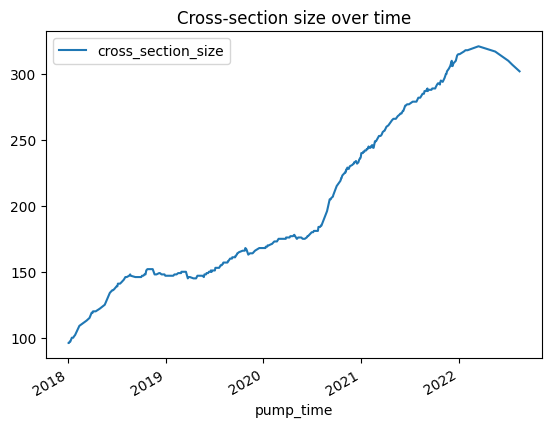

In [4]:
# cross-section statistics
(
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
plt.show()

<h4>Feature distributions and cross-sectional standardisation</h4>

<p>Now we will go through each FeatureType and display distribution stats and fix gaps in data</p>

<h4>Powerlaw features</h4>

In [5]:
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,83176.0,inf,NaN,-9.007199e+15,1.288491,1.425135,1.814165,inf
powerlaw_alpha@15MIN,90389.0,inf,NaN,-9.007199e+15,1.240540,1.324877,1.464839,inf
powerlaw_alpha@1H,92178.0,inf,NaN,1.086600e+00,1.199427,1.255902,1.332283,inf
powerlaw_alpha@2H,92223.0,inf,NaN,1.083316e+00,1.183039,1.231946,1.296669,inf
powerlaw_alpha@4H,92237.0,inf,NaN,1.085578e+00,1.168668,1.212866,1.267098,inf
powerlaw_alpha@12H,92258.0,1.204164,0.079963,1.085860e+00,1.153775,1.191352,1.234870,4.958618
powerlaw_alpha@1D,92261.0,1.191985,0.069083,1.084541e+00,1.147324,1.180051,1.220419,4.713602
powerlaw_alpha@2D,92310.0,1.181707,0.061434,1.042519e+00,1.141751,1.170982,1.208314,4.552822
powerlaw_alpha@7D,92485.0,1.168375,0.048692,1.041700e+00,1.134230,1.159121,1.192987,2.326308
powerlaw_alpha@14D,92661.0,1.162844,0.044515,1.041700e+00,1.130775,1.154292,1.186518,2.035152


In [6]:
# clip pawerlaw features to range [1, 2]
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,83176.0,1.532030,0.295659,1.000000,1.288491,1.425135,1.814165,2.0
powerlaw_alpha@15MIN,90389.0,1.398784,0.233052,1.000000,1.240540,1.324877,1.464839,2.0
powerlaw_alpha@1H,92178.0,1.283299,0.132082,1.086600,1.199427,1.255902,1.332283,2.0
powerlaw_alpha@2H,92223.0,1.251300,0.103687,1.083316,1.183039,1.231946,1.296669,2.0
powerlaw_alpha@4H,92237.0,1.228279,0.088869,1.085578,1.168668,1.212866,1.267098,2.0
powerlaw_alpha@12H,92258.0,1.203897,0.074788,1.085860,1.153775,1.191352,1.234870,2.0
powerlaw_alpha@1D,92261.0,1.191867,0.066480,1.084541,1.147324,1.180051,1.220419,2.0
powerlaw_alpha@2D,92310.0,1.181601,0.058761,1.042519,1.141751,1.170982,1.208314,2.0
powerlaw_alpha@7D,92485.0,1.168367,0.048532,1.041700,1.134230,1.159121,1.192987,2.0
powerlaw_alpha@14D,92661.0,1.162843,0.044501,1.041700,1.130775,1.154292,1.186518,2.0


In [7]:
df[powerlaw_cols].isna().sum()

powerlaw_alpha@5MIN     9853
powerlaw_alpha@15MIN    2640
powerlaw_alpha@1H        851
powerlaw_alpha@2H        806
powerlaw_alpha@4H        792
powerlaw_alpha@12H       771
powerlaw_alpha@1D        768
powerlaw_alpha@2D        719
powerlaw_alpha@7D        544
powerlaw_alpha@14D       368
dtype: int64

In [8]:
df[powerlaw_cols] = df[powerlaw_cols].fillna(-1)

<h4>Asset return features</h4>

<p><b>Note: returns are measured in pips</b></p>
<p>Here we observe that anticipated behaviour as time window grows the min/max and std become higher in absolute terms</p>

In [9]:
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return@5MIN,83175.0,3.539846,141.873713,-3333.333333,-19.080660,0.000000,20.686089,7000.000000
asset_return@15MIN,90388.0,5.120693,167.075719,-3333.333333,-31.156481,0.000000,34.603323,7000.000000
asset_return@1H,92176.0,7.406318,232.136653,-5410.958904,-65.703022,0.000000,64.102564,7288.135593
asset_return@2H,92216.0,8.067106,289.355256,-5000.000000,-96.339114,0.000000,83.333333,12371.541502
asset_return@4H,92222.0,21.139167,367.223518,-3875.968992,-126.756781,0.000000,123.456790,12549.800797
asset_return@12H,92200.0,35.268086,677.846154,-6392.125806,-211.267606,0.000000,203.488372,119032.258065
asset_return@1D,92185.0,31.192420,875.744848,-4814.814815,-334.316618,-27.855153,269.662921,119032.258065
asset_return@2D,92152.0,2.318001,1221.421779,-6050.000000,-508.474576,-79.630507,327.584269,119032.258065
asset_return@7D,91558.0,17.077679,4308.966670,-9999.946672,-1075.268817,-226.059874,615.713485,979361.702128
asset_return@14D,90897.0,70.294569,6523.776327,-9999.952116,-1600.000000,-403.006891,873.786408,979361.702128


In [10]:
df[asset_return_cols].isna().sum()

asset_return@5MIN     9854
asset_return@15MIN    2641
asset_return@1H        853
asset_return@2H        813
asset_return@4H        807
asset_return@12H       829
asset_return@1D        844
asset_return@2D        877
asset_return@7D       1471
asset_return@14D      2132
dtype: int64

<h4>Asset return zscores</h4>

In [11]:
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return_zscore@5MIN,81205.0,0.059321,1.248069,-14.091035,-0.467417,0.000000,0.451154,25.383653
asset_return_zscore@15MIN,81205.0,0.059321,1.248069,-14.091035,-0.467417,0.000000,0.451154,25.383653
asset_return_zscore@1H,92208.0,0.061172,1.014406,-14.091035,-0.384391,0.000000,0.397763,20.413539
asset_return_zscore@2H,92232.0,0.042986,0.735699,-7.602639,-0.301473,0.000000,0.301271,13.955420
asset_return_zscore@4H,92237.0,0.039590,0.542854,-6.030088,-0.220408,0.000749,0.229091,13.955420
asset_return_zscore@12H,92257.0,0.023507,0.301506,-2.251391,-0.124250,0.001143,0.137532,6.795124
asset_return_zscore@1D,92260.0,0.007973,0.194694,-1.767127,-0.097526,-0.005797,0.095553,1.892111
asset_return_zscore@2D,92307.0,-0.001343,0.136194,-2.123060,-0.075191,-0.007600,0.063614,4.823023
asset_return_zscore@7D,92479.0,-0.002920,0.081349,-2.123060,-0.046178,-0.003905,0.039029,4.974488
asset_return_zscore@14D,92652.0,-0.002517,0.061542,-2.308614,-0.035145,-0.002381,0.030157,4.972071


In [12]:
df[asset_return_zscore_cols].isna().sum()

asset_return_zscore@5MIN     11824
asset_return_zscore@15MIN    11824
asset_return_zscore@1H         821
asset_return_zscore@2H         797
asset_return_zscore@4H         792
asset_return_zscore@12H        772
asset_return_zscore@1D         769
asset_return_zscore@2D         722
asset_return_zscore@7D         550
asset_return_zscore@14D        377
dtype: int64

<h4>Quote abs zscore</h4>

In [13]:
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[quote_abs_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
quote_abs_zscore@5MIN,81205.0,0.126108,1.329861,-2.579978,-0.361765,-0.180713,0.119467,26.263573
quote_abs_zscore@15MIN,81205.0,0.126108,1.329861,-2.579978,-0.361765,-0.180713,0.119467,26.263573
quote_abs_zscore@1H,92208.0,0.119712,1.203549,-2.641997,-0.342723,-0.166038,0.128377,26.263573
quote_abs_zscore@2H,92232.0,0.102321,1.015910,-2.510568,-0.325692,-0.155033,0.134466,17.190673
quote_abs_zscore@4H,92237.0,0.086799,0.867164,-2.512795,-0.306628,-0.141730,0.134862,11.425492
quote_abs_zscore@12H,92257.0,0.017264,0.627528,-2.237507,-0.297820,-0.144083,0.094122,6.092637
quote_abs_zscore@1D,92260.0,-0.015500,0.520576,-2.144866,-0.290051,-0.143229,0.071714,4.622350
quote_abs_zscore@2D,92307.0,-0.018734,0.432933,-1.903089,-0.264354,-0.125284,0.088903,4.622350
quote_abs_zscore@7D,92479.0,-0.018442,0.275570,-1.296574,-0.197945,-0.071070,0.123966,1.901186
quote_abs_zscore@14D,92652.0,-0.016686,0.180594,-0.913495,-0.137189,-0.022492,0.101910,2.050641


<h4>Share of long trades</h4>

In [14]:
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[share_of_long_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
share_of_long_trades@5MIN,83176.0,0.517268,0.292531,0.000000,0.333333,0.500000,0.714286,1.000000
share_of_long_trades@15MIN,90389.0,0.518482,0.224703,0.000000,0.388889,0.517391,0.664336,1.000000
share_of_long_trades@1H,92178.0,0.517181,0.150249,0.000000,0.433333,0.517369,0.603774,1.000000
share_of_long_trades@2H,92223.0,0.516031,0.124298,0.000000,0.447445,0.515732,0.585880,1.000000
share_of_long_trades@4H,92237.0,0.517505,0.106134,0.000000,0.460765,0.515888,0.574194,1.000000
share_of_long_trades@12H,92258.0,0.518423,0.090379,0.000000,0.473163,0.516112,0.562183,0.995282
share_of_long_trades@1D,92261.0,0.519964,0.080382,0.028927,0.481622,0.516466,0.555286,0.993056
share_of_long_trades@2D,92310.0,0.521056,0.072479,0.047204,0.487039,0.516151,0.550318,0.989017
share_of_long_trades@7D,92485.0,0.523118,0.063910,0.083655,0.494262,0.516947,0.545596,0.976714
share_of_long_trades@14D,92661.0,0.525011,0.059946,0.093449,0.497412,0.517653,0.544994,0.962848


<h4>Slippage imbalance</h4>

In [15]:
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[slippage_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
slippage_imbalance@5MIN,51963.0,-0.045825,0.894400,-1.0,-1.000000,-0.203597,1.000000,1.0
slippage_imbalance@15MIN,71584.0,-0.062943,0.839990,-1.0,-0.992665,-0.185786,0.939368,1.0
slippage_imbalance@1H,86636.0,-0.103715,0.736776,-1.0,-0.853119,-0.201057,0.622171,1.0
slippage_imbalance@2H,89620.0,-0.119651,0.674076,-1.0,-0.757647,-0.190966,0.468534,1.0
slippage_imbalance@4H,91041.0,-0.122272,0.612953,-1.0,-0.659887,-0.173481,0.362258,1.0
slippage_imbalance@12H,91900.0,-0.126439,0.529661,-1.0,-0.532164,-0.155010,0.238582,1.0
slippage_imbalance@1D,92136.0,-0.129699,0.478849,-1.0,-0.467602,-0.152352,0.176985,1.0
slippage_imbalance@2D,92274.0,-0.129036,0.424993,-1.0,-0.402324,-0.143273,0.120882,1.0
slippage_imbalance@7D,92483.0,-0.108529,0.341115,-1.0,-0.299058,-0.119926,0.070548,1.0
slippage_imbalance@14D,92661.0,-0.098832,0.303030,-1.0,-0.259085,-0.110552,0.053645,1.0


In [16]:
df[slippage_imbalance_cols].isna().sum()

slippage_imbalance@5MIN     41066
slippage_imbalance@15MIN    21445
slippage_imbalance@1H        6393
slippage_imbalance@2H        3409
slippage_imbalance@4H        1988
slippage_imbalance@12H       1129
slippage_imbalance@1D         893
slippage_imbalance@2D         755
slippage_imbalance@7D         546
slippage_imbalance@14D        368
dtype: int64

<h4>Flow imbalance</h4>

In [17]:
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[flow_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
flow_imbalance@5MIN,83176.0,-0.013414,0.704083,-1.000000,-0.680634,-0.020261,0.644717,1.000000
flow_imbalance@15MIN,90389.0,-0.029935,0.581917,-1.000000,-0.482985,-0.031532,0.405582,1.000000
flow_imbalance@1H,92178.0,-0.045771,0.412345,-1.000000,-0.308347,-0.042699,0.207564,1.000000
flow_imbalance@2H,92223.0,-0.051732,0.334519,-1.000000,-0.248145,-0.045282,0.140321,1.000000
flow_imbalance@4H,92237.0,-0.046012,0.270830,-1.000000,-0.194336,-0.039754,0.100278,1.000000
flow_imbalance@12H,92258.0,-0.039562,0.201699,-1.000000,-0.143222,-0.037455,0.059132,0.993480
flow_imbalance@1D,92261.0,-0.034394,0.165865,-0.976580,-0.117182,-0.035160,0.039474,0.984582
flow_imbalance@2D,92310.0,-0.031868,0.138630,-0.976174,-0.100197,-0.035564,0.024604,0.967960
flow_imbalance@7D,92485.0,-0.023573,0.107280,-0.958871,-0.076927,-0.031297,0.012470,0.932742
flow_imbalance@14D,92661.0,-0.018755,0.096815,-0.895483,-0.068022,-0.028284,0.010833,0.907893


<h4>Num trades</h4>

In [18]:
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[num_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_trades@5MIN,93029.0,32.081093,100.757015,0.0,2.0,8.0,25.0,4987.0
num_trades@15MIN,93029.0,95.603231,276.483440,0.0,9.0,27.0,76.0,12184.0
num_trades@1H,93029.0,394.787400,1065.183223,0.0,47.0,123.0,329.0,33566.0
num_trades@2H,93029.0,784.716529,2105.999352,0.0,101.0,253.0,666.0,88326.0
num_trades@4H,93029.0,1546.035107,4027.671603,0.0,213.0,518.0,1343.0,137259.0
num_trades@12H,93029.0,4308.363145,10928.449191,0.0,637.0,1522.0,3822.0,437471.0
num_trades@1D,93029.0,8456.286158,21271.603490,0.0,1311.0,3059.0,7542.0,855882.0
num_trades@2D,93029.0,16950.288405,41283.156985,0.0,2803.0,6384.0,15315.0,1302688.0
num_trades@7D,93029.0,59459.953509,135055.043592,0.0,11318.0,24313.0,55288.0,3823480.0
num_trades@14D,93029.0,117521.348375,256354.157154,0.0,24297.0,50104.0,111741.0,6704862.0


In [19]:
# overall NaNs
df[df.isna().any(axis=1)].shape

(55566, 91)

<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [20]:
# plot feature distributions before cross-sectional standardisation
cols_to_scale: List[str] = asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols + powerlaw_cols

dfs: List[pd.DataFrame] = []

for i, (pump_hash, df_cross_section) in tqdm(enumerate(df.groupby("pump_hash"))):
    df_cross_section = df_cross_section.reset_index(drop=True)
    # Apply cross-sectional standardisation
    for col in cols_to_scale:
        df_cross_section[col] = (df_cross_section[col] - df_cross_section[col].mean()) / df_cross_section[col].std()
    df_cross_section["pump_id"] = i
    dfs.append(df_cross_section)

df_scaled: pd.DataFrame = pd.concat(dfs)
df_scaled = df_scaled.reset_index(drop=True)
df_scaled.head(2)

473it [00:03, 155.23it/s]


,asset_return@5MIN,asset_return_zscore@5MIN,quote_abs_zscore@5MIN,share_of_long_trades@5MIN,powerlaw_alpha@5MIN,slippage_imbalance@5MIN,flow_imbalance@5MIN,num_trades@5MIN,asset_return@15MIN,asset_return_zscore@15MIN,...,target_return@2MIN,target_return@3MIN,target_return@4MIN,target_return@5MIN,currency_pair,pump_hash,pump_time,pumped_currency_pair,is_pumped,pump_id
0,NaN,0.270176,0.043377,NaN,-2.212198,NaN,NaN,0,NaN,0.270176,...,NaN,NaN,18.832392,18.832392,RIF-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0
1,-7.330544,1.816101,-0.069575,0.0,0.786943,NaN,-1.0,1,0.095459,1.816101,...,NaN,NaN,0.000000,0.000000,SNGLS-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0


3it [00:00,  3.69it/s]


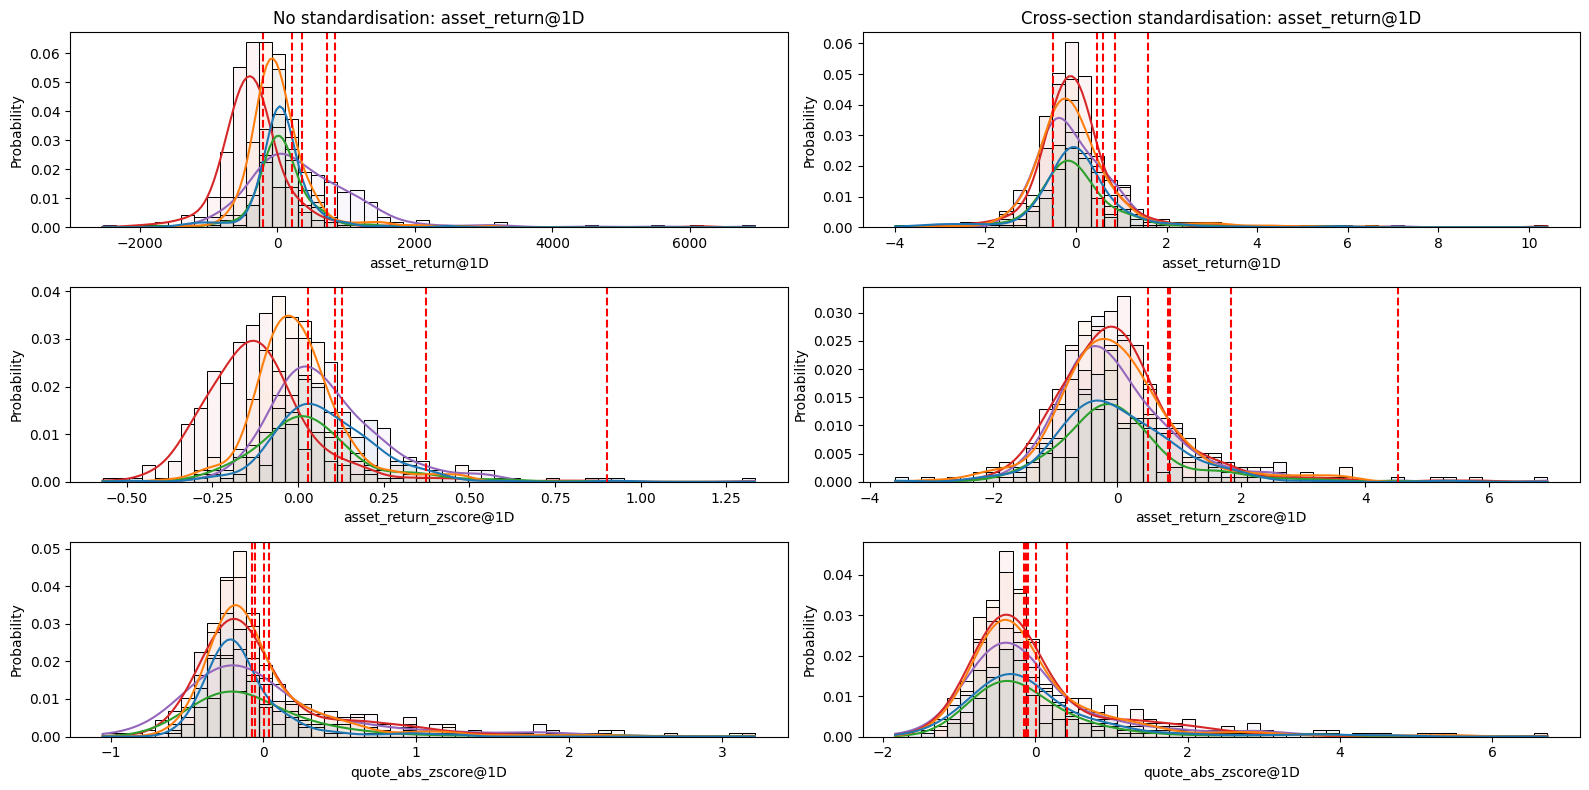

In [21]:
from core.time_utils import NamedTimeDelta
import seaborn as sns

groups_to_plot: List[FeatureType] = [
    FeatureType.ASSET_RETURN,
    FeatureType.ASSET_RETURN_ZSCORE,
    FeatureType.QUOTE_ABS_ZSCORE,
]

use_offset: NamedTimeDelta = NamedTimeDelta.ONE_DAY  # -> we will be plotting features from groups_to_plot at ONE_DAY offset
fig, axs = plt.subplots(len(groups_to_plot), 2, figsize=(16, 8))

# create two smaller dataframes with less cross-sections to plot
selected_pump_hashes: np.array = np.random.choice(
    df["pump_hash"].unique(), 5, replace=False
)  # use 5 pumps for plotting

_df_small: pd.DataFrame = df[df["pump_hash"].isin(selected_pump_hashes)]
_df_scaled_small: pd.DataFrame = df_scaled[df_scaled["pump_hash"].isin(selected_pump_hashes)]

feature: FeatureType
i = 0

for (ax1, ax2), feature in tqdm(zip(axs, groups_to_plot)):
    col_name: str = feature.col_name(offset=use_offset)
    # Plot pumps without standardisation
    sns.histplot(
        data=_df_small,
        x=col_name,
        hue="pump_hash",
        ax=ax1, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    if i == 0:
        ax1.set_title(f"No standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax1.axvline(
            x=_df_small.loc[_df_small["is_pumped"] & (_df_small["pump_hash"] == pump_hash), col_name].iloc[0],
            color="red", linestyle="--"
        )

    sns.histplot(
        data=_df_scaled_small,
        x=col_name,
        hue="pump_hash",
        ax=ax2, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    if i == 0:
        ax2.set_title(f"Cross-section standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax2.axvline(
            x=_df_scaled_small.loc[
                _df_scaled_small["is_pumped"] & (_df_scaled_small["pump_hash"] == pump_hash), col_name
            ].iloc[0],
            color="red", linestyle="--"
        )
    i+=1

plt.tight_layout()
plt.savefig("images/cs_standartization_impact.png")

<h4>Split data and train the first model</h4>

In [22]:
from analysis.utils.sample import Sample
from analysis.utils.feature_set import FeatureSet
from analysis.utils.experiment import Experiment

# use manually predefined set of features if we want to add more features we need to make sure to add them to FeatureSet.auto()
# FeatureSet defines the numeric/categorical regressors and target used for training, it is better to have this object passed around instead of multiple sets of features
# that's why we have it
feature_set: FeatureSet = FeatureSet.auto()

<h4>LogisticRegression model</h4>

In [23]:
from analysis.pipelines.LogisticRegression.pipe import LogisticRegressionPipeline
from analysis.pipelines.LogisticRegression.model import LogisticRegressionModel


pipe = LogisticRegressionPipeline()
sample = pipe.create_sample()

2025-11-04 00:53:47,076 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 322.42it/s]
2025-11-04 00:53:48,742 | WARNING | root | No data present for 25 pumps
2025-11-04 00:53:48,757 | INFO | root | Removing failed pump cross sections
2025-11-04 00:53:48,907 | WARNING | root | Removed 114 failed pumps
Filling missing values with cross-sectional medians: 100%|██████████| 359/359 [00:03<00:00, 94.25it/s] 
2025-11-04 00:53:53,055 | INFO | root | Nans
num_trades@5MIN     0
num_trades@15MIN    0
num_trades@1H       0
num_trades@2H       0
num_trades@4H       0
                   ..
asset_return@1D     0
asset_return@2D     0
asset_return@7D     0
asset_return@14D    0
num_prev_pump       0
Length: 81, dtype: int64
Applying cross section standardisation: 100%|██████████| 359/359 [00:02<00:00, 137.97it/s]
2025-11-04 00:53:55,832 | INFO | root | Dataset DatasetType.TRAIN. Shape (35115, 92)
2025-11-04 00:53:55,833 | INFO | root | Dat

In [24]:
model: LogisticRegressionModel = pipe.train(sample=sample, tuned=False)
experiment_lr = Experiment(experiment_name="LogisticRegression", model=model, sample=sample)

2025-11-04 00:53:55,836 | INFO | root | Training model


In [25]:
model: LogisticRegressionModel = pipe.train(sample=sample, tuned=True)
experiment_lr_tuned = Experiment(experiment_name="LogisticRegression + Tuned", model=model, sample=sample)

2025-11-04 00:53:57,991 | INFO | root | Training model


<h4>RandomForestClassifier</h4>

In [26]:
from analysis.pipelines.RandomForest.pipe import RandomForestPipeline
from analysis.pipelines.RandomForest.model import RandomForestModel


pipe = RandomForestPipeline()
sample: Sample = pipe.create_sample()

2025-11-04 00:54:03,974 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 326.87it/s]
2025-11-04 00:54:05,625 | WARNING | root | No data present for 25 pumps
2025-11-04 00:54:05,641 | INFO | root | Removing failed pump cross sections
2025-11-04 00:54:05,901 | WARNING | root | Removed 114 failed pumps
Applying cross section standardisation: 100%|██████████| 359/359 [00:02<00:00, 149.26it/s]
2025-11-04 00:54:08,599 | INFO | root | Dataset DatasetType.TRAIN. Shape (35115, 92)
2025-11-04 00:54:08,599 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17473, 92)
2025-11-04 00:54:08,600 | INFO | root | Dataset DatasetType.TEST. Shape (16950, 92)


In [27]:
model: RandomForestModel = pipe.train(sample, tuned=False)
experiment_rf = Experiment(experiment_name="RandomForestClassifier", model=model, sample=sample)

2025-11-04 00:54:08,603 | INFO | root | Training model


In [28]:
model: RandomForestModel = pipe.train(sample, tuned=True)
experiment_rf_tuned = Experiment(experiment_name="RandomForestClassifier + Tuned", model=model, sample=sample)

2025-11-04 00:54:10,572 | INFO | root | Training model


<h4>TOP-K or Hit ratio</h4>

<p>This metric measures the change of getting the only positive given we take K highest logits</p>

In [29]:
from analysis.utils.metrics import calculate_topk

?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TOP-K%</h4>

In [30]:
from analysis.utils.metrics import calculate_topk_percent

?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TOP-K% AUC</h4>

In [31]:
from analysis.utils.metrics import calculate_topk_percent_auc

?calculate_topk_percent_auc

Signature:
calculate_topk_percent_auc(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
) -> float
Docstring:
:return: If we iterate over all percentages from (0, 1) and compute TOPK% accuracy for each, we can measure overall
performance using AUC approach
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TopKPortfolio</h4>

In [32]:
from analysis.portfolio.TOPKPortfolio import TOPKPortfolio
from analysis.portfolio.BasePortfolio import PortfolioStats
from core.pump_event import PumpEvent
from core.currency_pair import CurrencyPair
from core.exchange import Exchange
from datetime import datetime

pump: PumpEvent = PumpEvent(
    currency_pair=CurrencyPair.from_string("ACM-BTC"),
    time=datetime.strptime("2021-06-05 18:00:13", "%Y-%m-%d %H:%M:%S"),
    exchange=Exchange.BINANCE_SPOT
)

manager = TOPKPortfolio(model=model, portfolio_size=5)

In [33]:
?manager.evaluate_for_pump

Signature:
manager.evaluate_for_pump(
    dataset: analysis.utils.sample.Dataset,
    pump: core.pump_event.PumpEvent,
) -> analysis.portfolio.BasePortfolio.PortfolioStats
Docstring:
:params cross_section: cross-section dataframe containing all features needed for model to make predictions
:params pump: pump event of the current cross-section
:returns: return of the portfolio selected by the model and corresponding portfolio
File:      ~/dev/pumps_and_dumps/src/analysis/portfolio/BasePortfolio.py
Type:      method

In [34]:
from analysis.utils.sample import DatasetType, Dataset

dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)
stats: List[PortfolioStats] = []

for pump in tqdm(dataset.get_pumps()):
    stats.append(
        manager.evaluate_for_pump(dataset=dataset, pump=pump)
    )

100%|██████████| 58/58 [01:59<00:00,  2.06s/it] 


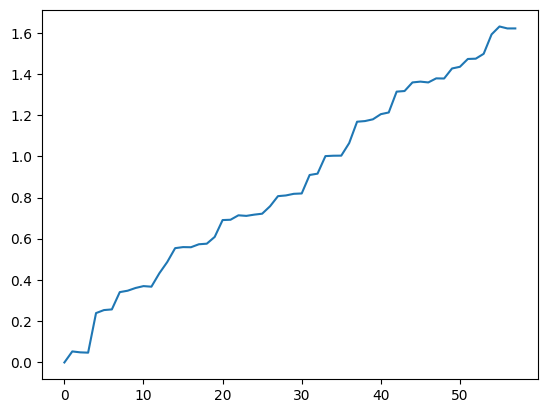

In [35]:
pnls = [stat.pnl for stat in stats]

plt.plot(np.array(pnls).cumsum())

<h4>CatboostClassifier</h4>

In [36]:
from analysis.pipelines.CatboostClassifier.pipe import CatboostClassifierPipeline
from analysis.pipelines.CatboostClassifier.model import CatboostClassifierModel


pipe = CatboostClassifierPipeline()
sample: Sample = pipe.create_sample()

2025-11-04 00:56:21,539 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 337.15it/s]
2025-11-04 00:56:23,133 | WARNING | root | No data present for 25 pumps
2025-11-04 00:56:23,148 | INFO | root | Removing failed pump cross sections
2025-11-04 00:56:23,280 | WARNING | root | Removed 114 failed pumps
Applying cross section standardisation: 100%|██████████| 359/359 [00:02<00:00, 147.34it/s]
2025-11-04 00:56:25,861 | INFO | root | Dataset DatasetType.TRAIN. Shape (35115, 92)
2025-11-04 00:56:25,861 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17473, 92)
2025-11-04 00:56:25,861 | INFO | root | Dataset DatasetType.TEST. Shape (16950, 92)


In [37]:
model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb = Experiment(experiment_name="CatboostClassifier", model=model, sample=sample)

In [38]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_tuned = Experiment(experiment_name="CatboostClassifier + Tuned", model=model, sample=sample)

<h4>CatboostClassifier + SMOTE</h4>

In [39]:
from analysis.pipelines.CatboostClassifierSMOTE.pipe import CatboostClassifierSMOTEPipeline

pipe = CatboostClassifierSMOTEPipeline()
sample: Sample = pipe.create_sample()

2025-11-04 00:56:27,950 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 300.03it/s]
2025-11-04 00:56:29,750 | WARNING | root | No data present for 25 pumps
2025-11-04 00:56:29,768 | INFO | root | Removing failed pump cross sections
2025-11-04 00:56:29,922 | WARNING | root | Removed 114 failed pumps
Applying cross section standardisation: 100%|██████████| 359/359 [00:02<00:00, 131.87it/s]
Filling missing values with cross-sectional medians: 100%|██████████| 359/359 [00:03<00:00, 97.95it/s] 
2025-11-04 00:56:36,800 | INFO | root | Nans
num_trades@5MIN     0
num_trades@15MIN    0
num_trades@1H       0
num_trades@2H       0
num_trades@4H       0
                   ..
asset_return@1D     0
asset_return@2D     0
asset_return@7D     0
asset_return@14D    0
num_prev_pump       0
Length: 81, dtype: int64
2025-11-04 00:56:36,837 | INFO | root | Dataset DatasetType.TRAIN. Shape (35115, 92)
2025-11-04 00:56:36,838 | INFO | root | Dat

In [40]:
model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb_smote = Experiment(experiment_name="CatboostClassifier + SMOTE", model=model, sample=sample)

In [41]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_smote_tuned = Experiment(experiment_name="CatboostClassifier + SMOTE + Tuned", model=model, sample=sample)

<h4>CatboostRanker</h4>

In [42]:
from analysis.pipelines.CatboostRanker.pipe import CatboostRankerPipeline
from analysis.pipelines.CatboostRanker.model import CatboostRankerModel

pipe = CatboostRankerPipeline()
sample: Sample = pipe.create_sample()

2025-11-04 00:57:15,093 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 264.00it/s]
2025-11-04 00:57:17,100 | WARNING | root | No data present for 25 pumps
2025-11-04 00:57:17,115 | INFO | root | Removing failed pump cross sections
2025-11-04 00:57:17,266 | WARNING | root | Removed 114 failed pumps
Applying cross section standardisation: 100%|██████████| 359/359 [00:02<00:00, 134.62it/s]
2025-11-04 00:57:20,105 | INFO | root | Dataset DatasetType.TRAIN. Shape (35115, 93)
2025-11-04 00:57:20,106 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17473, 93)
2025-11-04 00:57:20,106 | INFO | root | Dataset DatasetType.TEST. Shape (16950, 93)


In [43]:
model: CatboostRankerModel = pipe.train(sample, tuned=False)
experiment_cb_ranker = Experiment(experiment_name="CatboostRanker", model=model, sample=sample)

In [44]:
model: CatboostRankerModel = pipe.train(sample, tuned=True)
experiment_cb_ranker_tuned = Experiment(experiment_name="CatboostRanker + Tuned", model=model, sample=sample)

2025-11-04 00:57:21,678 | INFO | root | Loading parameters from CatboostRankerPipelineStudy


<h4>CatboostClassifier + TOPKAUC Early stopping</h4>

In [45]:
from analysis.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline

pipe = CatboostClassifierTOPKAUCPipeline()
sample: Sample = pipe.create_sample()

2025-11-04 00:57:23,012 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 283.22it/s]
2025-11-04 00:57:25,065 | WARNING | root | No data present for 25 pumps
2025-11-04 00:57:25,086 | INFO | root | Removing failed pump cross sections
2025-11-04 00:57:25,244 | WARNING | root | Removed 114 failed pumps
Applying cross section standardisation: 100%|██████████| 359/359 [00:02<00:00, 120.57it/s]
2025-11-04 00:57:28,386 | INFO | root | Dataset DatasetType.TRAIN. Shape (35115, 92)
2025-11-04 00:57:28,387 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17473, 92)
2025-11-04 00:57:28,387 | INFO | root | Dataset DatasetType.TEST. Shape (16950, 92)


In [46]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_topkauc_tuned = Experiment(experiment_name="CatboostClassifier + TOPKAUC Early Stopping", model=model, sample=sample)

/home/borokoko/.cache/pypoetry/virtualenvs/cryptocurrency-pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2321: UserWarning: Can't optimze method "evaluate" because self argument is used
  _check_train_params(params)


0:	learn: 0.8075771	test: 0.8191892	best: 0.8191892 (0)	total: 973ms	remaining: 16m 11s
10:	learn: 0.9210352	test: 0.9112162	best: 0.9112162 (10)	total: 9.53s	remaining: 14m 16s
20:	learn: 0.9339648	test: 0.9183784	best: 0.9183784 (20)	total: 18.6s	remaining: 14m 27s
30:	learn: 0.9466300	test: 0.9158108	best: 0.9183784 (20)	total: 27.5s	remaining: 14m 20s
40:	learn: 0.9524890	test: 0.9123649	best: 0.9183784 (20)	total: 36s	remaining: 14m 2s
50:	learn: 0.9572026	test: 0.9128378	best: 0.9183784 (20)	total: 43.7s	remaining: 13m 32s
60:	learn: 0.9604185	test: 0.9138514	best: 0.9183784 (20)	total: 52s	remaining: 13m 20s
70:	learn: 0.9652423	test: 0.9170946	best: 0.9183784 (20)	total: 60s	remaining: 13m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9183783784
bestIteration = 20

Shrink model to first 21 iterations.


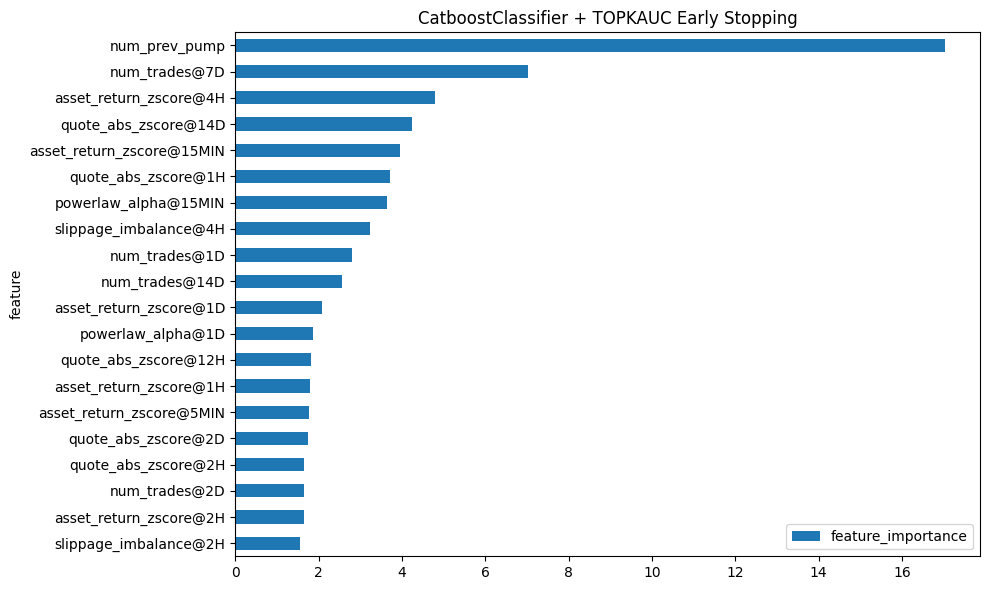

In [47]:
model = experiment_cb_topkauc_tuned.get_model()._model

df_fi = pd.DataFrame({
    "feature": model.feature_names_,
    "feature_importance": model.feature_importances_
})
df_fi = df_fi.set_index("feature").sort_values(by="feature_importance", ascending=True)

df_fi.tail(20).plot.barh(figsize=(10, 6))
plt.title("CatboostClassifier + TOPKAUC Early Stopping")
plt.tight_layout()
plt.savefig("images/feature_importances.png")

<h4>TOPK metric for all models</h4>

In [48]:
?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

In [49]:
from tqdm import tqdm
from analysis.pipelines.BaseModel import BaseModel, ImplementsRank


experiments: List[Experiment] = [
    experiment_lr,
    experiment_lr_tuned,
    experiment_rf,
    experiment_rf_tuned,
    experiment_cb,
    experiment_cb_tuned,
    experiment_cb_smote,
    experiment_cb_smote_tuned,
    experiment_cb_ranker,
    experiment_cb_ranker_tuned,
    experiment_cb_topkauc_tuned
]

In [50]:
topk_vals: Dict[str, List[float]] = {}

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    vals: List[float] = calculate_topk(
        model=model, dataset=sample.get_dataset(DatasetType.TEST), bins=[1, 2, 3, 5, 10, 20, 30]
    )
    topk_vals[name] = vals


df_topk: pd.DataFrame = pd.DataFrame(topk_vals)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]


styled = df_topk.T.style.apply(highlight_max, axis=0)
styled

100%|██████████| 11/11 [00:00<00:00, 18.22it/s]


,1,2,3,5,10,20,30
LogisticRegression,0.172414,0.224138,0.275862,0.379310,0.500000,0.672414,0.706897
LogisticRegression + Tuned,0.103448,0.155172,0.241379,0.344828,0.500000,0.706897,0.775862
RandomForestClassifier,0.155172,0.189655,0.258621,0.344828,0.448276,0.551724,0.689655
RandomForestClassifier + Tuned,0.137931,0.241379,0.310345,0.379310,0.534483,0.689655,0.775862
CatboostClassifier,0.155172,0.189655,0.293103,0.344828,0.413793,0.689655,0.810345
CatboostClassifier + Tuned,0.155172,0.275862,0.310345,0.396552,0.534483,0.724138,0.793103
CatboostClassifier + SMOTE,0.017241,0.103448,0.137931,0.172414,0.310345,0.448276,0.534483
CatboostClassifier + SMOTE + Tuned,0.034483,0.172414,0.206897,0.206897,0.310345,0.551724,0.586207
CatboostRanker,0.086207,0.120690,0.172414,0.241379,0.413793,0.517241,0.620690
CatboostRanker + Tuned,0.103448,0.155172,0.241379,0.310345,0.431034,0.551724,0.586207


In [51]:
cols = [col for col in df_topk.columns if col.endswith("Tuned")] + ["CatboostClassifier + TOPKAUC Early Stopping"]

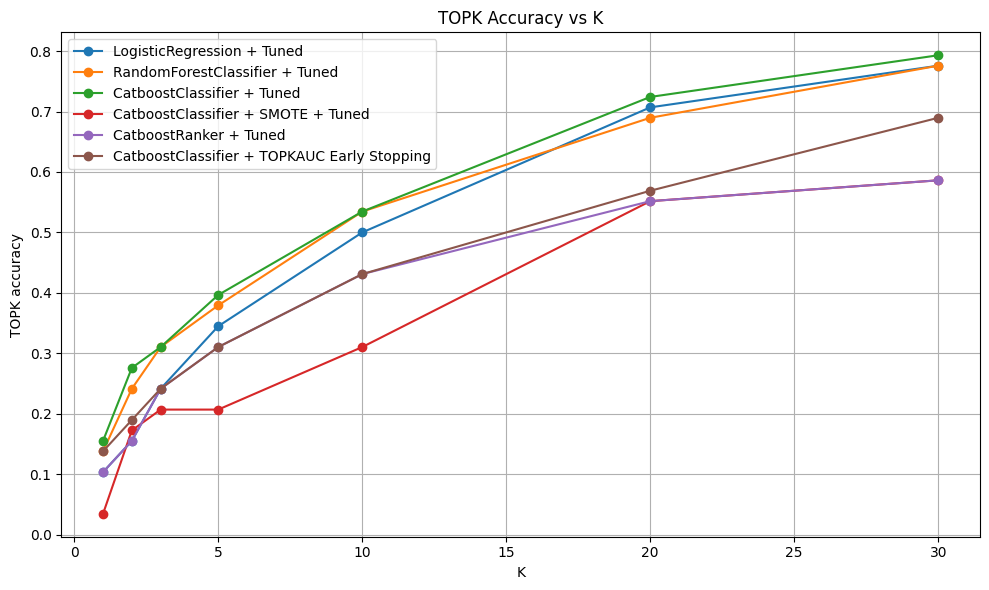

In [52]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
df_topk[cols].plot(ax=ax, marker="o")
plt.ylabel("TOPK accuracy")
plt.xlabel("K")
plt.title("TOPK Accuracy vs K")
plt.grid()
plt.tight_layout()
plt.savefig("images/topk_accuracy_test.png")

<h4>TOPK% for models</h4>

In [53]:
topkp_vals: Dict[str, List[float]] = {}

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    vals: List[float] = calculate_topk_percent(model=model, dataset=sample.get_dataset(DatasetType.TEST), bins=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
    topkp_vals[name] = vals

df_topkp: pd.DataFrame = pd.DataFrame(topkp_vals)

styled = df_topkp.style.apply(highlight_max, axis=1)
styled

100%|██████████| 11/11 [00:00<00:00, 16.67it/s]


,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.010000,0.275862,0.293103,0.275862,0.310345,0.310345,0.327586,0.137931,0.206897,0.172414,0.241379,0.258621
0.020000,0.396552,0.362069,0.413793,0.431034,0.362069,0.482759,0.189655,0.275862,0.275862,0.327586,0.362069
0.050000,0.568966,0.603448,0.500000,0.620690,0.586207,0.637931,0.413793,0.431034,0.500000,0.482759,0.517241
0.100000,0.706897,0.775862,0.706897,0.758621,0.810345,0.793103,0.534483,0.586207,0.603448,0.586207,0.689655
0.200000,0.827586,0.879310,0.775862,0.896552,0.862069,0.862069,0.672414,0.724138,0.741379,0.724138,0.827586
0.500000,0.965517,0.965517,0.913793,0.982759,0.982759,0.982759,0.896552,0.965517,0.827586,0.862069,0.982759


<h4>TOPK% curves for all models</h4>

In [54]:
topkp_vals: Dict[str, List[float]] = {}
auc_scores: List[float] = []

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    dataset: Dataset = sample.get_dataset(DatasetType.TEST)
    vals: List[float] = calculate_topk_percent(model=model, dataset=dataset, bins=np.arange(0, 1.01, 0.01))
    topkp_vals[name] = vals
    auc_scores.append(
        calculate_topk_percent_auc(model=model, dataset=dataset)
    )

df_topkp = pd.DataFrame(topkp_vals)

100%|██████████| 11/11 [00:05<00:00,  1.96it/s]


In [55]:
df_topkp

,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.00,0.172414,0.103448,0.155172,0.137931,0.155172,0.155172,0.017241,0.034483,0.086207,0.103448,0.137931
0.01,0.275862,0.293103,0.275862,0.310345,0.310345,0.327586,0.137931,0.206897,0.172414,0.241379,0.258621
0.02,0.396552,0.362069,0.413793,0.431034,0.362069,0.482759,0.189655,0.275862,0.275862,0.327586,0.362069
0.03,0.482759,0.500000,0.448276,0.517241,0.396552,0.534483,0.293103,0.293103,0.396552,0.431034,0.431034
0.04,0.568966,0.603448,0.465517,0.568966,0.551724,0.534483,0.362069,0.344828,0.465517,0.448276,0.482759
...,...,...,...,...,...,...,...,...,...,...,...
0.96,1.000000,1.000000,0.982759,1.000000,1.000000,1.000000,1.000000,1.000000,0.965517,0.948276,0.982759
0.97,1.000000,1.000000,0.982759,1.000000,1.000000,1.000000,1.000000,1.000000,0.965517,0.965517,1.000000
0.98,1.000000,1.000000,0.982759,1.000000,1.000000,1.000000,1.000000,1.000000,0.965517,0.982759,1.000000
0.99,1.000000,1.000000,0.982759,1.000000,1.000000,1.000000,1.000000,1.000000,0.982759,0.982759,1.000000


In [56]:
legends = [f"{experiment.experiment_name} - {round(score, 3)}" for experiment, score in zip(experiments, auc_scores) if experiment.experiment_name in cols]
X = np.arange(0, 1.01, 0.01)

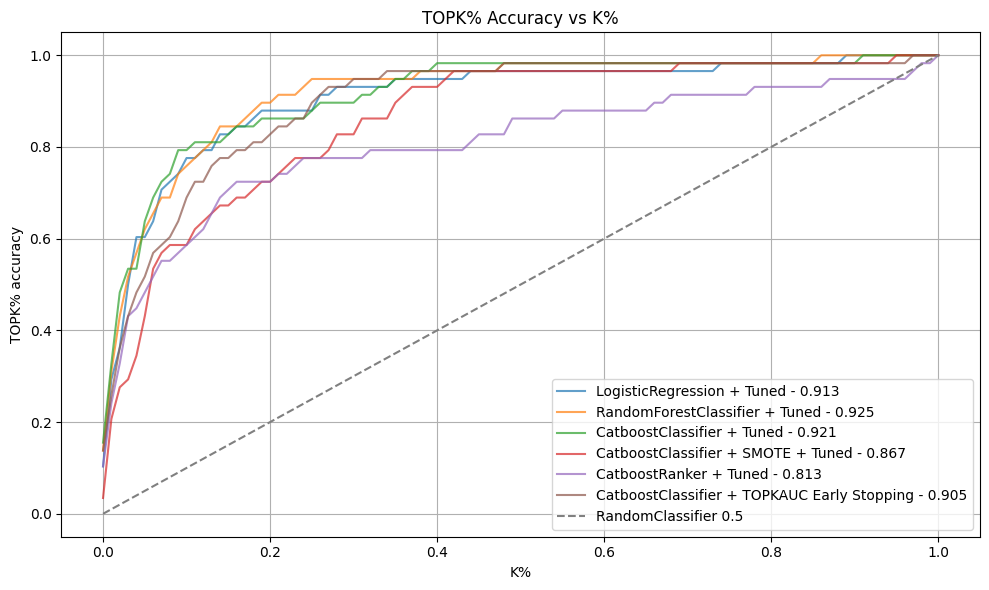

In [57]:
df_topkp[cols].plot(figsize=(10, 6), alpha=0.7)
plt.plot(X, X, linestyle="--", color="grey", label="RandomClassifier")
plt.legend(legends + ["RandomClassifier 0.5"])
plt.xlabel("K%")
plt.ylabel("TOPK% accuracy")
plt.title("TOPK% Accuracy vs K%")
plt.grid()
plt.tight_layout()
plt.savefig("images/topkp_auc_test.png")

<h4>Test Sample PnL</h4>

In [58]:
def get_equity_curve_for_experiment(experiment: Experiment, portfolio_size: int = 5) -> np.ndarray:
    sample: Sample = experiment.get_sample()
    manager = TOPKPortfolio(model=experiment.get_model(), portfolio_size=portfolio_size)
    dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)
    
    stats: List[PortfolioStats] = []

    for pump in tqdm(
        sorted(dataset.get_pumps()), 
        desc=f"Computing equity curve for {experiment.get_experiment_name()} amd K={portfolio_size}"
    ):
        stats.append(
            manager.evaluate_for_pump(dataset=dataset, pump=pump)
        )

    return np.array([stat.pnl for stat in stats])

In [59]:
equity_curves: Dict[str, np.ndarray] = {}

for experiment in experiments:
    equity_curves[experiment.experiment_name] = get_equity_curve_for_experiment(experiment=experiment)

Computing equity curve for LogisticRegression amd K=5:  71%|███████   | 41/58 [00:17<00:04,  3.84it/s]2025-11-04 00:58:54,010 | INFO | root | No data to get prices for DLT-BTC
Computing equity curve for LogisticRegression amd K=5:  72%|███████▏  | 42/58 [00:17<00:04,  3.75it/s]2025-11-04 00:58:54,196 | INFO | root | No data to get prices for DLT-BTC
Computing equity curve for LogisticRegression amd K=5:  86%|████████▌ | 50/58 [00:19<00:01,  4.29it/s]2025-11-04 00:58:56,093 | INFO | root | No data to get prices for EVX-BTC
Computing equity curve for LogisticRegression amd K=5:  88%|████████▊ | 51/58 [00:19<00:01,  4.39it/s]2025-11-04 00:58:56,323 | INFO | root | No data to get prices for EVX-BTC
Computing equity curve for LogisticRegression amd K=5:  90%|████████▉ | 52/58 [00:20<00:01,  4.38it/s]2025-11-04 00:58:56,490 | INFO | root | No data to get prices for EVX-BTC
Computing equity curve for LogisticRegression amd K=5:  93%|█████████▎| 54/58 [00:20<00:00,  4.23it/s]2025-11-04 00:58:5

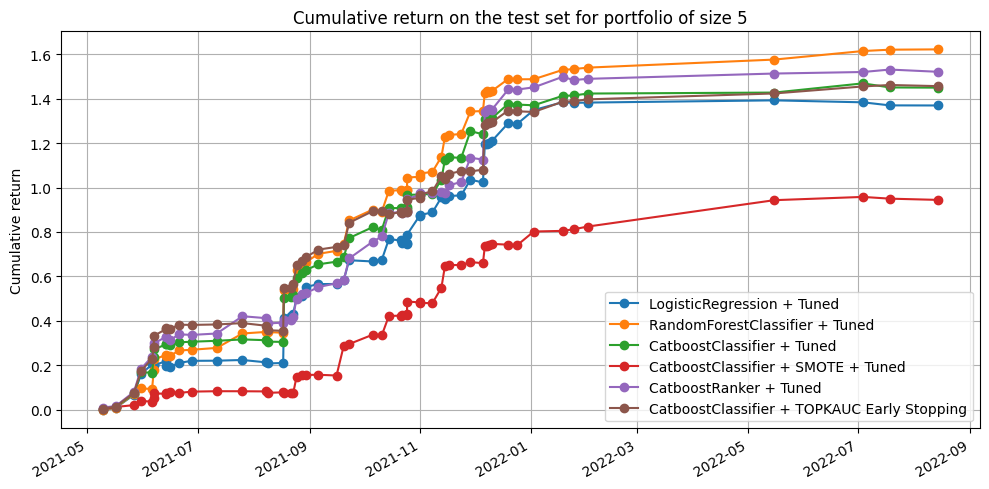

In [61]:
df_curves = pd.DataFrame(equity_curves)
index = [pump.time for pump in sorted(sample.get_dataset(DatasetType.TEST).get_pumps())]

df_curves.index = index

df_curves[cols].cumsum().plot(figsize=(10, 5), marker="o")
plt.title("Cumulative return on the test set for portfolio of size 5")
plt.ylabel("Cumulative return")

plt.grid()
plt.tight_layout()
plt.savefig("images/portfolios_test.png")

<h4>Portfolio performance for TOPKAUC ES Model</h4>

In [62]:
curves: Dict[int, np.ndarray] = {}

for k in [1, 2, 5, 10, 20, 30]:
    curves[k] = get_equity_curve_for_experiment(experiment=experiment_cb_topkauc_tuned, portfolio_size=k)

Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=1: 100%|██████████| 58/58 [00:11<00:00,  5.19it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=2: 100%|██████████| 58/58 [00:14<00:00,  4.08it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=5: 100%|██████████| 58/58 [00:21<00:00,  2.69it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=10: 100%|██████████| 58/58 [00:35<00:00,  1.62it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=20: 100%|██████████| 58/58 [01:02<00:00,  1.08s/it]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=30: 100%|██████████| 58/58 [01:27<00:00,  1.51s/it]


In [63]:
pd.DataFrame(curves).agg(["min", "mean", "median", "std", "max"]).T

,min,mean,median,std,max
1,-0.068667,0.043106,0.011622,0.095767,0.429151
2,-0.039681,0.033959,0.009354,0.061406,0.252771
5,-0.020570,0.025113,0.009187,0.042577,0.202168
10,-0.011285,0.016624,0.007484,0.024707,0.116979
20,-0.008037,0.010331,0.005452,0.014163,0.068667
30,-0.009178,0.007108,0.004983,0.010266,0.048995
